# Cross sections
This notebook computes and plots cross sections spanning longitudinally, across a small latitude strip. Each composite is based on a time the user selects under the "TC times" list. Right now, it's set to the time of TC geneis relative to when it happened in nature. So the code loops through each ensemble member within a selected set, finds that time, and composites it with the rest of the ensemble members. 

In [2]:
import pkg_resources
from __future__ import print_function
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import pandas as pd
import os
import glob
from netCDF4 import Dataset, num2date, date2num

#from AEW_module import season, AEW, AEW_CCKW

from metpy.units import units
import geocat.viz as gv


import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker 

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import wrf
from wrf import (to_np, interplevel, geo_bounds, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, destagger)

import seaborn as sns
import metpy.calc as mpcalc

In [3]:
## The following are lists to select each ensemble set and respective initialization time
variation = ['fluxon', 'rst_on24', 'rst_on36', 'rst_on48', '', 'fluxoff', '', '', '']
init_times = ['0300','0303','0306',
             '0309','0312','0315',
             '0318','0321','0400']

In [4]:
#########################################
### MAKE SELECTIONS HERE
#set = 'Fluxes on'          # try: '24 hours without fluxes'
set_name = variation[1]     # try: variation[1]
wave = 'second'             # 'second' == Paulette or 'main' == Rene
title = '24 hrs decoupled'  # What will be displayed on main plot

In [5]:
plotsdir = '/glade/u/home/athornton/qtrack/'

In [6]:
### Common time to composite across. Currently set to 
# when TC genesis occurred for Hurricane Paulette in nature

# The length of this list should corespond to the length
# of the init_times list (or number of ensemble members)
tc_times = ['2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00']

In [7]:
# tc_times = ['2020-09-08 12:00:00',
#            '2020-09-08 12:00:00',
#            '2020-09-08 12:00:00',
#            '2020-09-08 12:00:00',
#            '2020-09-08 12:00:00',
#            '2020-09-08 12:00:00',
#            '2020-09-08 12:00:00',
#            '2020-09-08 12:00:00',
#            '2020-09-08 12:00:00']

In [9]:
vort_slice_list = []
v_slice_list = []
qwv_slice_list = []
for time,ens in zip(tc_times,init_times):
    try:
        os.chdir("/glade/campaign/univ/uncs0067/flux_experiments/cent_atl_case/init"+ens+"z/"+set_name+"/")
        datafiles = sorted(glob.glob("./wrfout*"))
        numfiles=len(datafiles)
        print(ens)
        print(time)
        dates_list = pd.date_range(start='2020-09-'+ens[:2]+' '+ens[2:]+':00:00', end='2020-09-09 12:00:00', freq='3h')
        date_index = np.squeeze(np.where(dates_list == time))
                
        ncfile = Dataset(datafiles[date_index])
        Time=wrf.extract_times(ncfile, timeidx=0, method='cat', squeeze=True, cache=None, meta=False, do_xtime=False)
        timestr=(str(Time))
        # Set up one time string for plot titles, another for file names
        titletime=(timestr[0:10]+' '+timestr[11:16])
        filetime=(timestr[0:10]+'_'+timestr[11:16])
        print('WRF valid time: ',filetime)

        wrf_out_data = xr.open_dataset(datafiles[date_index])  

        # Get sea level pressure and wind variables
        ua = wrf_out_data["U"]
        va = wrf_out_data["V"]
        p = wrf_out_data["P"]
        pb = wrf_out_data["PB"]
        qwv = wrf_out_data["QVAPOR"]
        #pvo = getvar(ncfile, "pvo")

        # Unstagger the winds to match the pressure grid
        ua = destagger(ua, stagger_dim=3)  # Unstagger U in the x-direction
        va = destagger(va, stagger_dim=2)  # Unstagger V in the x-direction
        
        # Grid spacing for vorticity calculation
        dx = ncfile.DX * units("m")
        dy = ncfile.DY * units("m")
        
        u_winds = xr.DataArray(ua)
        v_winds = xr.DataArray(va)
        pres = xr.DataArray(p)
        pb = xr.DataArray(pb)
        lats, lons = latlon_coords(wrf_out_data['P'])
        lats_np = to_np(lats)
        lons_np = to_np(lons)
        u_winds = u_winds[0]
        v_winds = v_winds[0]
        pres = pres[0]
        pb = pb[0,:,0,0]
        qwv = qwv[0]
        pb = pb.metpy.convert_units('mbar')
        
        lat_min = 15   # This window will be averaged across
        lat_max = 20   # This window will be averaged across
        lon_min = -70  # Select how long you want the cross section to be
        lon_max = -10  # Select how long you want the cross section to be
        lat = lats_np[0,:,0]
        lon = lons_np[0,0,:]

        # Select the indices that correspond to the lat/lon windows
        idx = np.where(lat <= lat_min)
        min_lat_idx = idx[0][-1]
        idx = np.where(lat <= lat_max)
        max_lat_idx = idx[0][-1]
        
        idx = np.where(lon <= lon_min)
        min_lon_idx = idx[0][-1]
        idx = np.where(lon <= lon_max)
        max_lon_idx = idx[0][-1]
        
        u_winds2 = u_winds*units('m/s')
        v_winds2 = v_winds*units('m/s')

        
        vo = mpcalc.vorticity(u_winds2, v_winds2, dx=dx, dy=dy)
        vo = vo.sel(dim_2=slice(min_lat_idx,max_lat_idx), dim_3=slice(min_lon_idx,max_lon_idx)).mean(dim='dim_2')
        v_winds = v_winds.sel(dim_2=slice(min_lat_idx,max_lat_idx), dim_3=slice(min_lon_idx,max_lon_idx)).mean(dim='dim_2')
        qwv = qwv.sel(south_north=slice(min_lat_idx,max_lat_idx), west_east=slice(min_lon_idx,max_lon_idx)).mean(dim='south_north')

        vort_slice_list.append(vo)
        v_slice_list.append(v_winds)
        qwv_slice_list.append(qwv)
        
        pres2 = pres.sel(south_north=slice(min_lat_idx,max_lat_idx), west_east=slice(min_lon_idx,max_lon_idx)).mean(dim='south_north')
        bottom_top = pres2.bottom_top
        west_east = pres2.west_east
        lon_slice = lon[min_lon_idx:max_lon_idx]

    # Skip the ones that do not 
    except TypeError:
        print('skipping')
        pass

0300
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_19906/2879682785.py:76: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds2, v_winds2, dx=dx, dy=dy)


0303
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_19906/2879682785.py:76: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds2, v_winds2, dx=dx, dy=dy)


0306
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


...

/glade/derecho/scratch/athornton/tmp/ipykernel_19906/2879682785.py:76: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds2, v_winds2, dx=dx, dy=dy)


0321
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_19906/2879682785.py:76: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds2, v_winds2, dx=dx, dy=dy)


0400
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_19906/2879682785.py:76: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_winds2, v_winds2, dx=dx, dy=dy)


In [10]:
# Take the average along the time dimension
vort = xr.DataArray(vort_slice_list).mean(dim='dim_0')
v = xr.DataArray(v_slice_list).mean(dim='dim_0')
moist = xr.DataArray(qwv_slice_list).mean(dim='dim_0')

Text(1.0, 1.0, 'Ensemble Set: 24 hrs decoupled\nDate: 2020-09-07_12:00z\nLatitude: 15-20N')

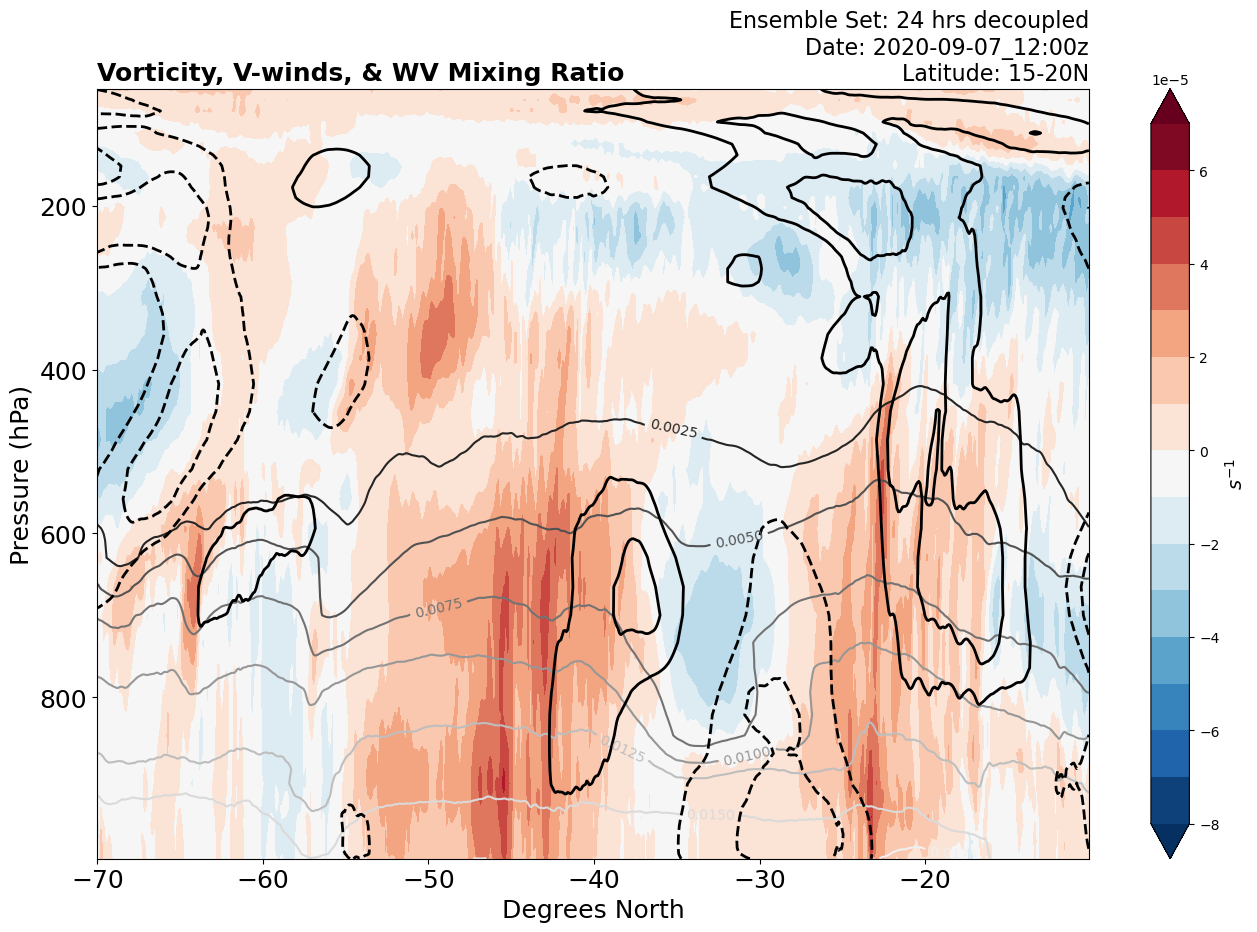

In [12]:
# Fig quality
plt.rcParams['savefig.dpi'] = 255

fig = plt.figure(figsize=(16,10))
ax = plt.axes()
plt.gca().invert_yaxis()
#levels = np.arange(-0.0005, 0.0005, 0.00005)
levels = np.arange(-0.00008, 0.00008, 0.00001)
cf = ax.contourf(lon_slice, pb, vort, levels=levels, cmap='RdBu_r', extend='both')
cb = plt.colorbar(cf)
cb.set_label('$s^{-1}$', fontsize=14)

#levels = np.arange(0.0015, 0.0150, 0.0025)
cs = ax.contour(lon_slice, pb, moist, cmap='Greys_r')
ax.clabel(cs, inline=True, fontsize=10)

#levels2 = [-5, -3, -1, 1, 3, 5]
levels2 = [-5, -3, 3, 5]

cs2 = ax.contour(lon_slice, pb, v, colors='black', levels=levels2, linewidths=2.)

ax.set_xlabel('Degrees North', fontsize=18)
ax.set_ylabel('Pressure (hPa)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
#plt.yscale("log")
plt.title('Vorticity, V-winds, & WV Mixing Ratio', loc='left', weight='bold', fontsize=18)
plt.title('Ensemble Set: '+str(title)+
          '\nDate: '+str(filetime)+
          'z\nLatitude: '+str(lat_min)+'-'+str(lat_max)+'N', 
          loc='right', fontsize=16)
#plt.savefig(plotsdir+'SHIFTcross_section_vort_wv_v_'+set_name+'_'+filetime+'.png')